
# Module 11 - Discussion Notebook


**Objective:** Explore how **spatial joins** and **overlays** can answer city-planning questions like:  
*“Where do incidents occur relative to schools, and which neighborhoods might need safety interventions?”*

You will run this notebook to generate sample maps and summary metrics, then **share your observations** on the discussion board.

> This notebook uses **synthetic data** (no downloads needed).  
> **GeoPandas is not required.**



## Setup

This notebook uses:
- `numpy` and `pandas` for data creation and wrangling  
- `matplotlib` for static plots (**one plot per figure**)  
- Optional: `shapely` (not required). If unavailable, everything still runs.

Run the cells top-to-bottom.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: shapely (not required)
try:
    from shapely.geometry import Point
    SHAPELY_OK = True
except Exception:
    SHAPELY_OK = False

plt.rcParams['figure.figsize'] = (8, 6)
SHAPELY_OK


True


## 1) Generate a Synthetic City and Datasets

We simulate a city as a rectangle in longitude/latitude space, then create:
- **Schools** (points)
- **Traffic accidents / incidents** (points)

We also inject a few clusters near random schools to mimic hotspots.


In [2]:

rng = np.random.default_rng(42)

# Synthetic city bounding box
lon_min, lon_max = -84.6, -84.2
lat_min, lat_max = 33.6, 33.9

def random_points(n):
    lons = rng.uniform(lon_min, lon_max, size=n)
    lats = rng.uniform(lat_min, lat_max, size=n)
    return pd.DataFrame({'lon': lons, 'lat': lats})

schools = random_points(20)
accidents = random_points(400)

# Add clusters near 5 random schools
for idx in rng.choice(schools.index, size=5, replace=False):
    cx, cy = schools.loc[idx, 'lon'], schools.loc[idx, 'lat']
    jitter = rng.normal(0, 0.01, size=(60, 2))
    clust = pd.DataFrame({'lon': cx + jitter[:, 0], 'lat': cy + jitter[:, 1]})
    accidents = pd.concat([accidents, clust], ignore_index=True)

schools.head(), accidents.head()


(         lon        lat
 0 -84.290418  33.827426
 1 -84.424449  33.706358
 2 -84.256561  33.891209
 3 -84.321053  33.867936
 4 -84.562329  33.833515,
          lon        lat
 0 -84.425139  33.855339
 1 -84.266929  33.646564
 2 -84.319894  33.820386
 3 -84.475053  33.657912
 4 -84.267096  33.681228)


## 2) Point Map — Where are Schools and Accidents?

This scatter plot is a simple **point map**:
- Accidents are plotted as dots  
- Schools are plotted as triangles  

Use it to visually identify clustering and spread.


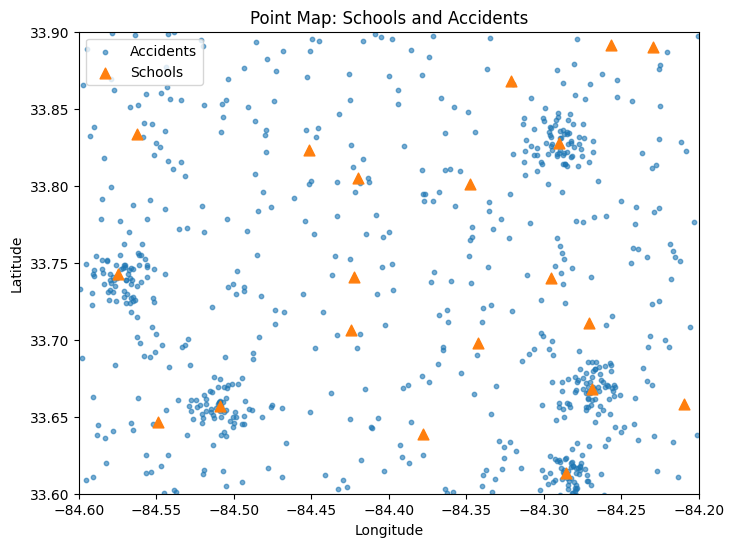

In [3]:

fig, ax = plt.subplots()
ax.scatter(accidents['lon'], accidents['lat'], s=10, alpha=0.6, label='Accidents')
ax.scatter(schools['lon'], schools['lat'], s=60, marker='^', label='Schools')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.legend()
ax.set_title("Point Map: Schools and Accidents")
plt.show()



## 3) Choropleth-Style Density View — Accident Counts by Grid Cell

We divide the city into a grid and compute **accident counts per cell**.  
This behaves like a choropleth because each grid cell represents a region.


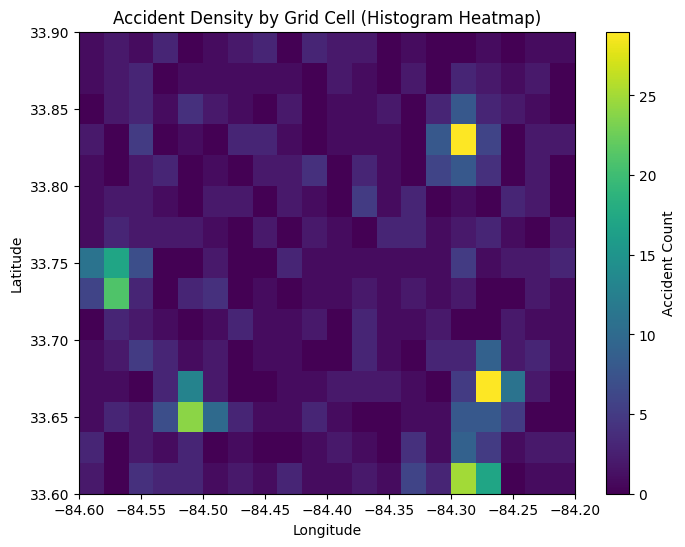

In [4]:

nx, ny = 20, 15
heat, xedges, yedges = np.histogram2d(
    accidents['lon'], accidents['lat'],
    bins=[nx, ny],
    range=[[lon_min, lon_max], [lat_min, lat_max]]
)

fig, ax = plt.subplots()
im = ax.imshow(
    heat.T,
    origin='lower',
    extent=[lon_min, lon_max, lat_min, lat_max],
    aspect='auto'
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Accident Density by Grid Cell (Histogram Heatmap)")
plt.colorbar(im, ax=ax, label="Accident Count")
plt.show()



## 4) Proximity Analysis — Accidents Near Schools (Spatial Join Concept)

We approximate a **spatial join** by asking:

> How many accidents occur within **1 km** of each school?

We use the **Haversine** distance formula for longitude/latitude points.


In [5]:

threshold_m = 1000  # 1 km

def haversine(lon1, lat1, lon2, lat2):
    R = 6371000.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2.0)**2
    return 2*R*np.arcsin(np.sqrt(a))

near_counts = []
for i, row in schools.iterrows():
    d = haversine(row['lon'], row['lat'], accidents['lon'].values, accidents['lat'].values)
    near_counts.append((i, int((d <= threshold_m).sum())))

near_df = pd.DataFrame(near_counts, columns=['school_idx', 'accidents_within_1km'])
near_df['lon'] = schools.loc[near_df['school_idx'], 'lon'].values
near_df['lat'] = schools.loc[near_df['school_idx'], 'lat'].values
near_df.sort_values('accidents_within_1km', ascending=False).head()


,school_idx,accidents_within_1km,lon,lat
7,7,28,-84.285574,33.613141
18,18,25,-84.268948,33.668073
0,0,24,-84.290418,33.827426
15,15,23,-84.509105,33.656841
17,17,22,-84.574473,33.742711



### Visualization: School Buffers (Display) and Accident Points

We draw **approximate buffer circles** (for display only).  
Counting is still done with Haversine distances.


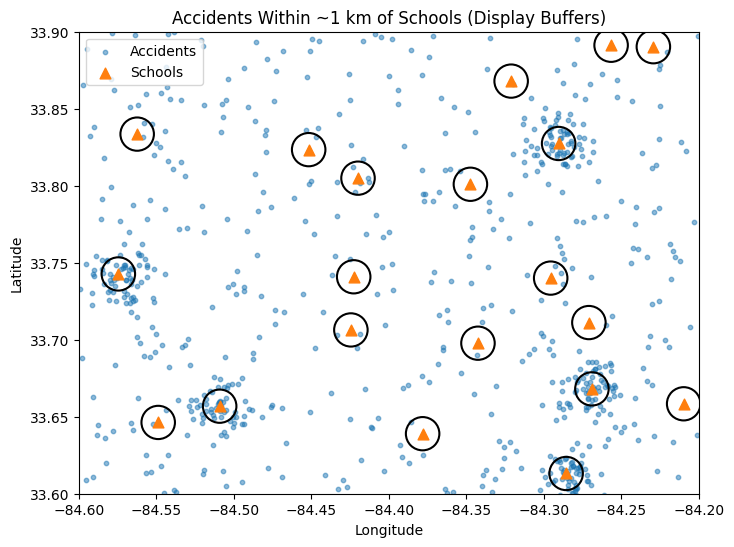

In [6]:

fig, ax = plt.subplots()
ax.scatter(accidents['lon'], accidents['lat'], s=10, alpha=0.5, label='Accidents')
ax.scatter(schools['lon'], schools['lat'], s=60, marker='^', label='Schools')

# Convert 1 km to degrees (approx) for display radius
center_lat = (lat_min + lat_max) / 2
meters_per_deg_lon = 111_320 * np.cos(np.radians(center_lat))
deg_r = threshold_m / meters_per_deg_lon

for _, r in schools.iterrows():
    circ = plt.Circle((r['lon'], r['lat']), deg_r, fill=False, linewidth=1.5)
    ax.add_patch(circ)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_title("Accidents Within ~1 km of Schools (Display Buffers)")
ax.legend()
plt.show()



## 5) Summary Metrics

We report:
- Total accidents  
- Unique accidents within 1 km of **any** school  
- Top-5 schools with the most nearby accidents


In [7]:

total_accidents = int(len(accidents))

def any_near(acc_row):
    d = haversine(acc_row['lon'], acc_row['lat'], schools['lon'].values, schools['lat'].values)
    return bool((d <= threshold_m).any())

unique_near = int(accidents.apply(any_near, axis=1).sum())

print("Total accidents in city:", total_accidents)
print("Unique accidents within 1 km of any school:", unique_near)

print("\nTop-5 schools by accidents within 1 km:")
near_df.sort_values('accidents_within_1km', ascending=False).head(5)


Total accidents in city: 700
Unique accidents within 1 km of any school: 138

Top-5 schools by accidents within 1 km:


,school_idx,accidents_within_1km,lon,lat
7,7,28,-84.285574,33.613141
18,18,25,-84.268948,33.668073
0,0,24,-84.290418,33.827426
15,15,23,-84.509105,33.656841
17,17,22,-84.574473,33.742711
